In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

# Phase 1:
df = pd.read_csv(r"D:\do_an_2_clustering\data\CC GENERAL.csv")
# ============================================================
# PHASE 2. DATA AUDIT
# Assumption: df is already loaded successfully.
# Example:
#   df = pd.read_csv(...)
# ============================================================


# ------------------------------------------------------------
# 1. Basic validation
# ------------------------------------------------------------
def validate_input_dataframe(df: pd.DataFrame) -> None:
    if not isinstance(df, pd.DataFrame):
        raise TypeError("df must be a pandas DataFrame.")
    if df.empty:
        raise ValueError("df is empty.")
    if df.columns.duplicated().any():
        dup_cols = df.columns[df.columns.duplicated()].tolist()
        raise ValueError(f"Duplicate column names found: {dup_cols}")


# ------------------------------------------------------------
# 2. Helper functions
# ------------------------------------------------------------
def get_numeric_columns(df: pd.DataFrame) -> list[str]:
    return df.select_dtypes(include=[np.number]).columns.tolist()


def safe_skew(series: pd.Series) -> float:
    s = series.dropna()
    if len(s) < 3:
        return np.nan
    return float(skew(s, bias=False))


def safe_kurtosis(series: pd.Series) -> float:
    s = series.dropna()
    if len(s) < 4:
        return np.nan
    return float(kurtosis(s, bias=False, fisher=True))


def infer_frequency_columns(df: pd.DataFrame) -> list[str]:
    """
    Detect likely frequency/probability columns.
    In this dataset, columns containing 'FREQUENCY' and PRC_FULL_PAYMENT
    are expected to be in [0, 1].
    """
    freq_cols = [c for c in df.columns if "FREQUENCY" in c.upper()]
    if "PRC_FULL_PAYMENT" in df.columns:
        freq_cols.append("PRC_FULL_PAYMENT")
    return sorted(set(freq_cols))


def infer_nonnegative_columns(df: pd.DataFrame) -> list[str]:
    """
    In the credit card clustering dataset, most numeric columns should be nonnegative.
    """
    numeric_cols = get_numeric_columns(df)
    return [c for c in numeric_cols if c != "TENURE"]


def infer_positive_expected_columns(df: pd.DataFrame) -> list[str]:
    """
    Columns that should generally be > 0 to avoid downstream ratio issues.
    Zero may exist in practice, so this is a soft audit check, not a hard filter.
    """
    candidates = ["TENURE", "CREDIT_LIMIT"]
    return [c for c in candidates if c in df.columns]


# ------------------------------------------------------------
# 3. Core audit tables
# ------------------------------------------------------------
def build_schema_report(df: pd.DataFrame) -> pd.DataFrame:
    """
    Schema and health overview for every column.
    """
    report = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null_count": df.notna().sum(),
        "missing_count": df.isna().sum(),
        "missing_rate_pct": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(dropna=True),
    })

    numeric_cols = get_numeric_columns(df)

    report["min"] = np.nan
    report["max"] = np.nan
    report["mean"] = np.nan
    report["std"] = np.nan
    report["median"] = np.nan
    report["skewness"] = np.nan
    report["kurtosis"] = np.nan

    for col in numeric_cols:
        s = df[col]
        report.loc[col, "min"] = s.min(skipna=True)
        report.loc[col, "max"] = s.max(skipna=True)
        report.loc[col, "mean"] = s.mean(skipna=True)
        report.loc[col, "std"] = s.std(skipna=True)
        report.loc[col, "median"] = s.median(skipna=True)
        report.loc[col, "skewness"] = safe_skew(s)
        report.loc[col, "kurtosis"] = safe_kurtosis(s)

    return report.sort_values(["missing_rate_pct", "dtype"], ascending=[False, True])


def build_dataset_summary(df: pd.DataFrame) -> pd.DataFrame:
    """
    Small summary table for the whole dataset.
    """
    summary = {
        "n_rows": len(df),
        "n_columns": df.shape[1],
        "n_numeric_columns": len(get_numeric_columns(df)),
        "duplicate_rows": int(df.duplicated().sum()),
        "duplicate_row_rate_pct": round(df.duplicated().mean() * 100, 4),
        "any_missing": bool(df.isna().any().any()),
        "total_missing_cells": int(df.isna().sum().sum()),
        "total_missing_rate_pct": round(df.isna().sum().sum() / (df.shape[0] * df.shape[1]) * 100, 4),
    }
    return pd.DataFrame([summary])


def build_missingness_report(df: pd.DataFrame) -> pd.DataFrame:
    report = pd.DataFrame({
        "column": df.columns,
        "missing_count": df.isna().sum().values,
        "missing_rate_pct": (df.isna().mean() * 100).round(2).values
    })
    return report.sort_values(["missing_rate_pct", "missing_count"], ascending=[False, False]).reset_index(drop=True)


def build_duplicate_report(df: pd.DataFrame) -> dict:
    dup_mask = df.duplicated(keep=False)
    duplicate_rows_df = df.loc[dup_mask].copy()
    return {
        "duplicate_count": int(df.duplicated().sum()),
        "duplicate_rate_pct": round(df.duplicated().mean() * 100, 4),
        "duplicate_rows_preview": duplicate_rows_df.head(10)
    }


# ------------------------------------------------------------
# 4. Logical audit
# ------------------------------------------------------------
def audit_frequency_constraints(df: pd.DataFrame) -> pd.DataFrame:
    """
    Frequency-like variables should usually lie in [0, 1].
    """
    rows = []
    for col in infer_frequency_columns(df):
        s = df[col]
        invalid_low = int((s < 0).sum(skipna=True))
        invalid_high = int((s > 1).sum(skipna=True))
        invalid_total = invalid_low + invalid_high

        rows.append({
            "column": col,
            "rule": "0 <= value <= 1",
            "invalid_low_count": invalid_low,
            "invalid_high_count": invalid_high,
            "invalid_total_count": invalid_total,
            "invalid_rate_pct": round(invalid_total / len(df) * 100, 4),
            "min_value": s.min(skipna=True),
            "max_value": s.max(skipna=True),
        })

    return pd.DataFrame(rows).sort_values("invalid_total_count", ascending=False)


def audit_nonnegative_constraints(df: pd.DataFrame) -> pd.DataFrame:
    """
    Monetary/count-like variables should generally be >= 0.
    """
    rows = []
    for col in infer_nonnegative_columns(df):
        s = df[col]
        invalid_neg = int((s < 0).sum(skipna=True))
        rows.append({
            "column": col,
            "rule": "value >= 0",
            "invalid_negative_count": invalid_neg,
            "invalid_rate_pct": round(invalid_neg / len(df) * 100, 4),
            "min_value": s.min(skipna=True),
        })

    result = pd.DataFrame(rows)
    return result[result["invalid_negative_count"] > 0].sort_values(
        "invalid_negative_count", ascending=False
    ).reset_index(drop=True)


def audit_soft_positive_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Soft check only. Zero does not necessarily mean invalid, but it matters
    for later feature engineering such as LIMIT_USAGE or monthly averages.
    """
    rows = []
    for col in infer_positive_expected_columns(df):
        s = df[col]
        zero_count = int((s == 0).sum(skipna=True))
        negative_count = int((s < 0).sum(skipna=True))
        rows.append({
            "column": col,
            "zero_count": zero_count,
            "negative_count": negative_count,
            "zero_rate_pct": round(zero_count / len(df) * 100, 4),
            "negative_rate_pct": round(negative_count / len(df) * 100, 4),
            "min_value": s.min(skipna=True),
            "median_value": s.median(skipna=True),
        })

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# 5. Distribution and outlier audit
# ------------------------------------------------------------
def build_distribution_report(df: pd.DataFrame) -> pd.DataFrame:
    """
    Summarize numeric distribution shape and IQR-based outlier burden.
    """
    rows = []
    for col in get_numeric_columns(df):
        s = df[col].dropna()
        if s.empty:
            continue

        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_mask = (s < lower) | (s > upper)

        rows.append({
            "column": col,
            "skewness": round(safe_skew(s), 4),
            "kurtosis": round(safe_kurtosis(s), 4),
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower,
            "upper_bound": upper,
            "outlier_count_iqr": int(outlier_mask.sum()),
            "outlier_rate_iqr_pct": round(outlier_mask.mean() * 100, 2),
        })

    report = pd.DataFrame(rows)

    def shape_label(x: float) -> str:
        if pd.isna(x):
            return "unknown"
        if x > 1:
            return "high_right_skew"
        if x > 0.5:
            return "moderate_right_skew"
        if x < -1:
            return "high_left_skew"
        if x < -0.5:
            return "moderate_left_skew"
        return "roughly_symmetric"

    report["shape_label"] = report["skewness"].apply(shape_label)
    return report.sort_values(["outlier_rate_iqr_pct", "skewness"], ascending=[False, False]).reset_index(drop=True)


def suggest_log1p_candidates(distribution_report: pd.DataFrame, skew_threshold: float = 1.0) -> list[str]:
    """
    Conservative suggestion list for later preprocessing.
    This is only an audit output. It does not transform anything yet.
    """
    candidates = distribution_report.loc[
        distribution_report["skewness"] >= skew_threshold, "column"
    ].tolist()

    # In this dataset, log1p is usually more defensible for monetary totals than for bounded ratios.
    exclude_keywords = ["FREQUENCY", "RATIO", "PRC_"]
    filtered = []
    for col in candidates:
        upper_col = col.upper()
        if any(k in upper_col for k in exclude_keywords):
            continue
        filtered.append(col)
    return filtered


# ------------------------------------------------------------
# 6. Optional plotting utilities
# ------------------------------------------------------------
def plot_numeric_histograms(df: pd.DataFrame, columns: list[str] | None = None, n_cols: int = 3, bins: int = 30) -> None:
    if columns is None:
        columns = get_numeric_columns(df)

    if not columns:
        print("No numeric columns to plot.")
        return

    n_rows = int(np.ceil(len(columns) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(columns):
        ax = axes[i]
        s = df[col].dropna()
        ax.hist(s, bins=bins)
        ax.set_title(f"{col}\nSkew={safe_skew(s):.2f}")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


def plot_boxplots(df: pd.DataFrame, columns: list[str] | None = None, n_cols: int = 3) -> None:
    if columns is None:
        columns = get_numeric_columns(df)

    if not columns:
        print("No numeric columns to plot.")
        return

    n_rows = int(np.ceil(len(columns) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(columns):
        ax = axes[i]
        ax.boxplot(df[col].dropna(), vert=True)
        ax.set_title(col)
        ax.set_xticks([])

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


def plot_missingness_bar(missing_report: pd.DataFrame, top_n: int = 20) -> None:
    plot_df = missing_report.head(top_n).copy()
    if plot_df.empty:
        print("No missingness to plot.")
        return

    plt.figure(figsize=(10, 5))
    plt.bar(plot_df["column"], plot_df["missing_rate_pct"])
    plt.xticks(rotation=60, ha="right")
    plt.ylabel("Missing rate (%)")
    plt.title(f"Top {min(top_n, len(plot_df))} columns by missingness")
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 7. Main audit runner
# ------------------------------------------------------------
def run_phase_2_data_audit(
    df: pd.DataFrame,
    id_columns: list[str] | None = None,
    show_plots: bool = True
) -> dict:
    """
    Phase 2 runner.

    Parameters
    ----------
    df : pd.DataFrame
        Already loaded raw dataset.
    id_columns : list[str] | None
        Identifier columns to ignore in some reports, if desired.
        Example: ['CUST_ID']
    show_plots : bool
        Whether to render histogram, boxplot, and missingness charts.

    Returns
    -------
    dict of audit artifacts.
    """
    validate_input_dataframe(df)

    audit_df = df.copy()

    # Keep raw df intact, but allow excluding ID columns from numeric-distribution review if needed
    if id_columns is None:
        id_columns = []
    id_columns = [c for c in id_columns if c in audit_df.columns]

    numeric_cols_for_plots = [c for c in get_numeric_columns(audit_df) if c not in id_columns]

    dataset_summary = build_dataset_summary(audit_df)
    schema_report = build_schema_report(audit_df)
    missingness_report = build_missingness_report(audit_df)
    duplicate_report = build_duplicate_report(audit_df)
    frequency_audit = audit_frequency_constraints(audit_df)
    nonnegative_audit = audit_nonnegative_constraints(audit_df)
    positive_soft_audit = audit_soft_positive_columns(audit_df)
    distribution_report = build_distribution_report(audit_df[[c for c in audit_df.columns if c not in id_columns]])

    log1p_candidates = suggest_log1p_candidates(distribution_report, skew_threshold=1.0)

    audit_results = {
        "dataset_summary": dataset_summary,
        "schema_report": schema_report,
        "missingness_report": missingness_report,
        "duplicate_report": duplicate_report,
        "frequency_audit": frequency_audit,
        "nonnegative_audit": nonnegative_audit,
        "positive_soft_audit": positive_soft_audit,
        "distribution_report": distribution_report,
        "suggested_log1p_candidates": log1p_candidates,
    }

    # Display key tables
    print("=" * 80)
    print("PHASE 2. DATA AUDIT")
    print("=" * 80)

    print("\n[Dataset Summary]")
    print(dataset_summary.to_string(index=False))

    print("\n[Top Missing Columns]")
    print(missingness_report.head(15).to_string(index=False))

    print("\n[Frequency Constraint Audit]")
    if frequency_audit.empty:
        print("No frequency-like columns detected.")
    else:
        print(frequency_audit.to_string(index=False))

    print("\n[Nonnegative Constraint Violations]")
    if nonnegative_audit.empty:
        print("No negative-value violations detected in numeric columns.")
    else:
        print(nonnegative_audit.to_string(index=False))

    print("\n[Soft Positive Columns Audit]")
    print(positive_soft_audit.to_string(index=False))

    print("\n[Most Skewed / Outlier-Heavy Numeric Features]")
    print(distribution_report.head(15).to_string(index=False))

    print("\n[Suggested log1p candidates for later preprocessing]")
    print(log1p_candidates)

    print("\n[Duplicate Rows]")
    print(f"duplicate_count = {duplicate_report['duplicate_count']}")
    print(f"duplicate_rate_pct = {duplicate_report['duplicate_rate_pct']}")

    if show_plots:
        plot_missingness_bar(missingness_report, top_n=20)
        plot_numeric_histograms(audit_df, columns=numeric_cols_for_plots, n_cols=3, bins=30)
        plot_boxplots(audit_df, columns=numeric_cols_for_plots, n_cols=3)

    return audit_results


# ============================================================
# EXAMPLE USAGE
# ============================================================
# If your raw loaded dataframe still contains CUST_ID, pass it here
# so plots and some numeric-shape reports ignore the identifier.
#
# audit_results = run_phase_2_data_audit(
#     df=df,
#     id_columns=["CUST_ID"],
#     show_plots=True
# )
#
# Then access:
# audit_results["schema_report"]
# audit_results["missingness_report"]
# audit_results["distribution_report"]
# audit_results["suggested_log1p_candidates"]

PHASE 2. DATA AUDIT

[Dataset Summary]
 n_rows  n_columns  n_numeric_columns  duplicate_rows  duplicate_row_rate_pct  any_missing  total_missing_cells  total_missing_rate_pct
   8950         18                 17               0                     0.0         True                  314                  0.1949

[Top Missing Columns]
                          column  missing_count  missing_rate_pct
                MINIMUM_PAYMENTS            313              3.50
                    CREDIT_LIMIT              1              0.01
                         CUST_ID              0              0.00
                         BALANCE              0              0.00
               BALANCE_FREQUENCY              0              0.00
                       PURCHASES              0              0.00
                ONEOFF_PURCHASES              0              0.00
          INSTALLMENTS_PURCHASES              0              0.00
                    CASH_ADVANCE              0              0.00
      

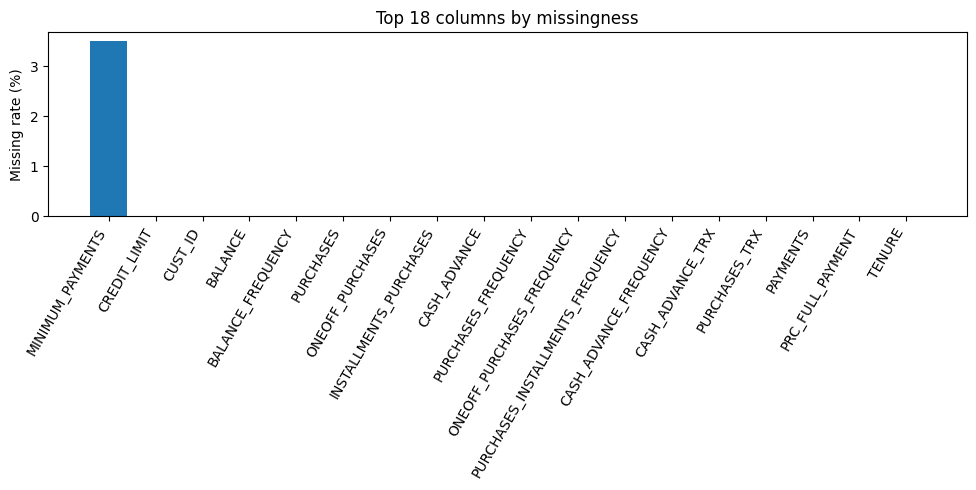

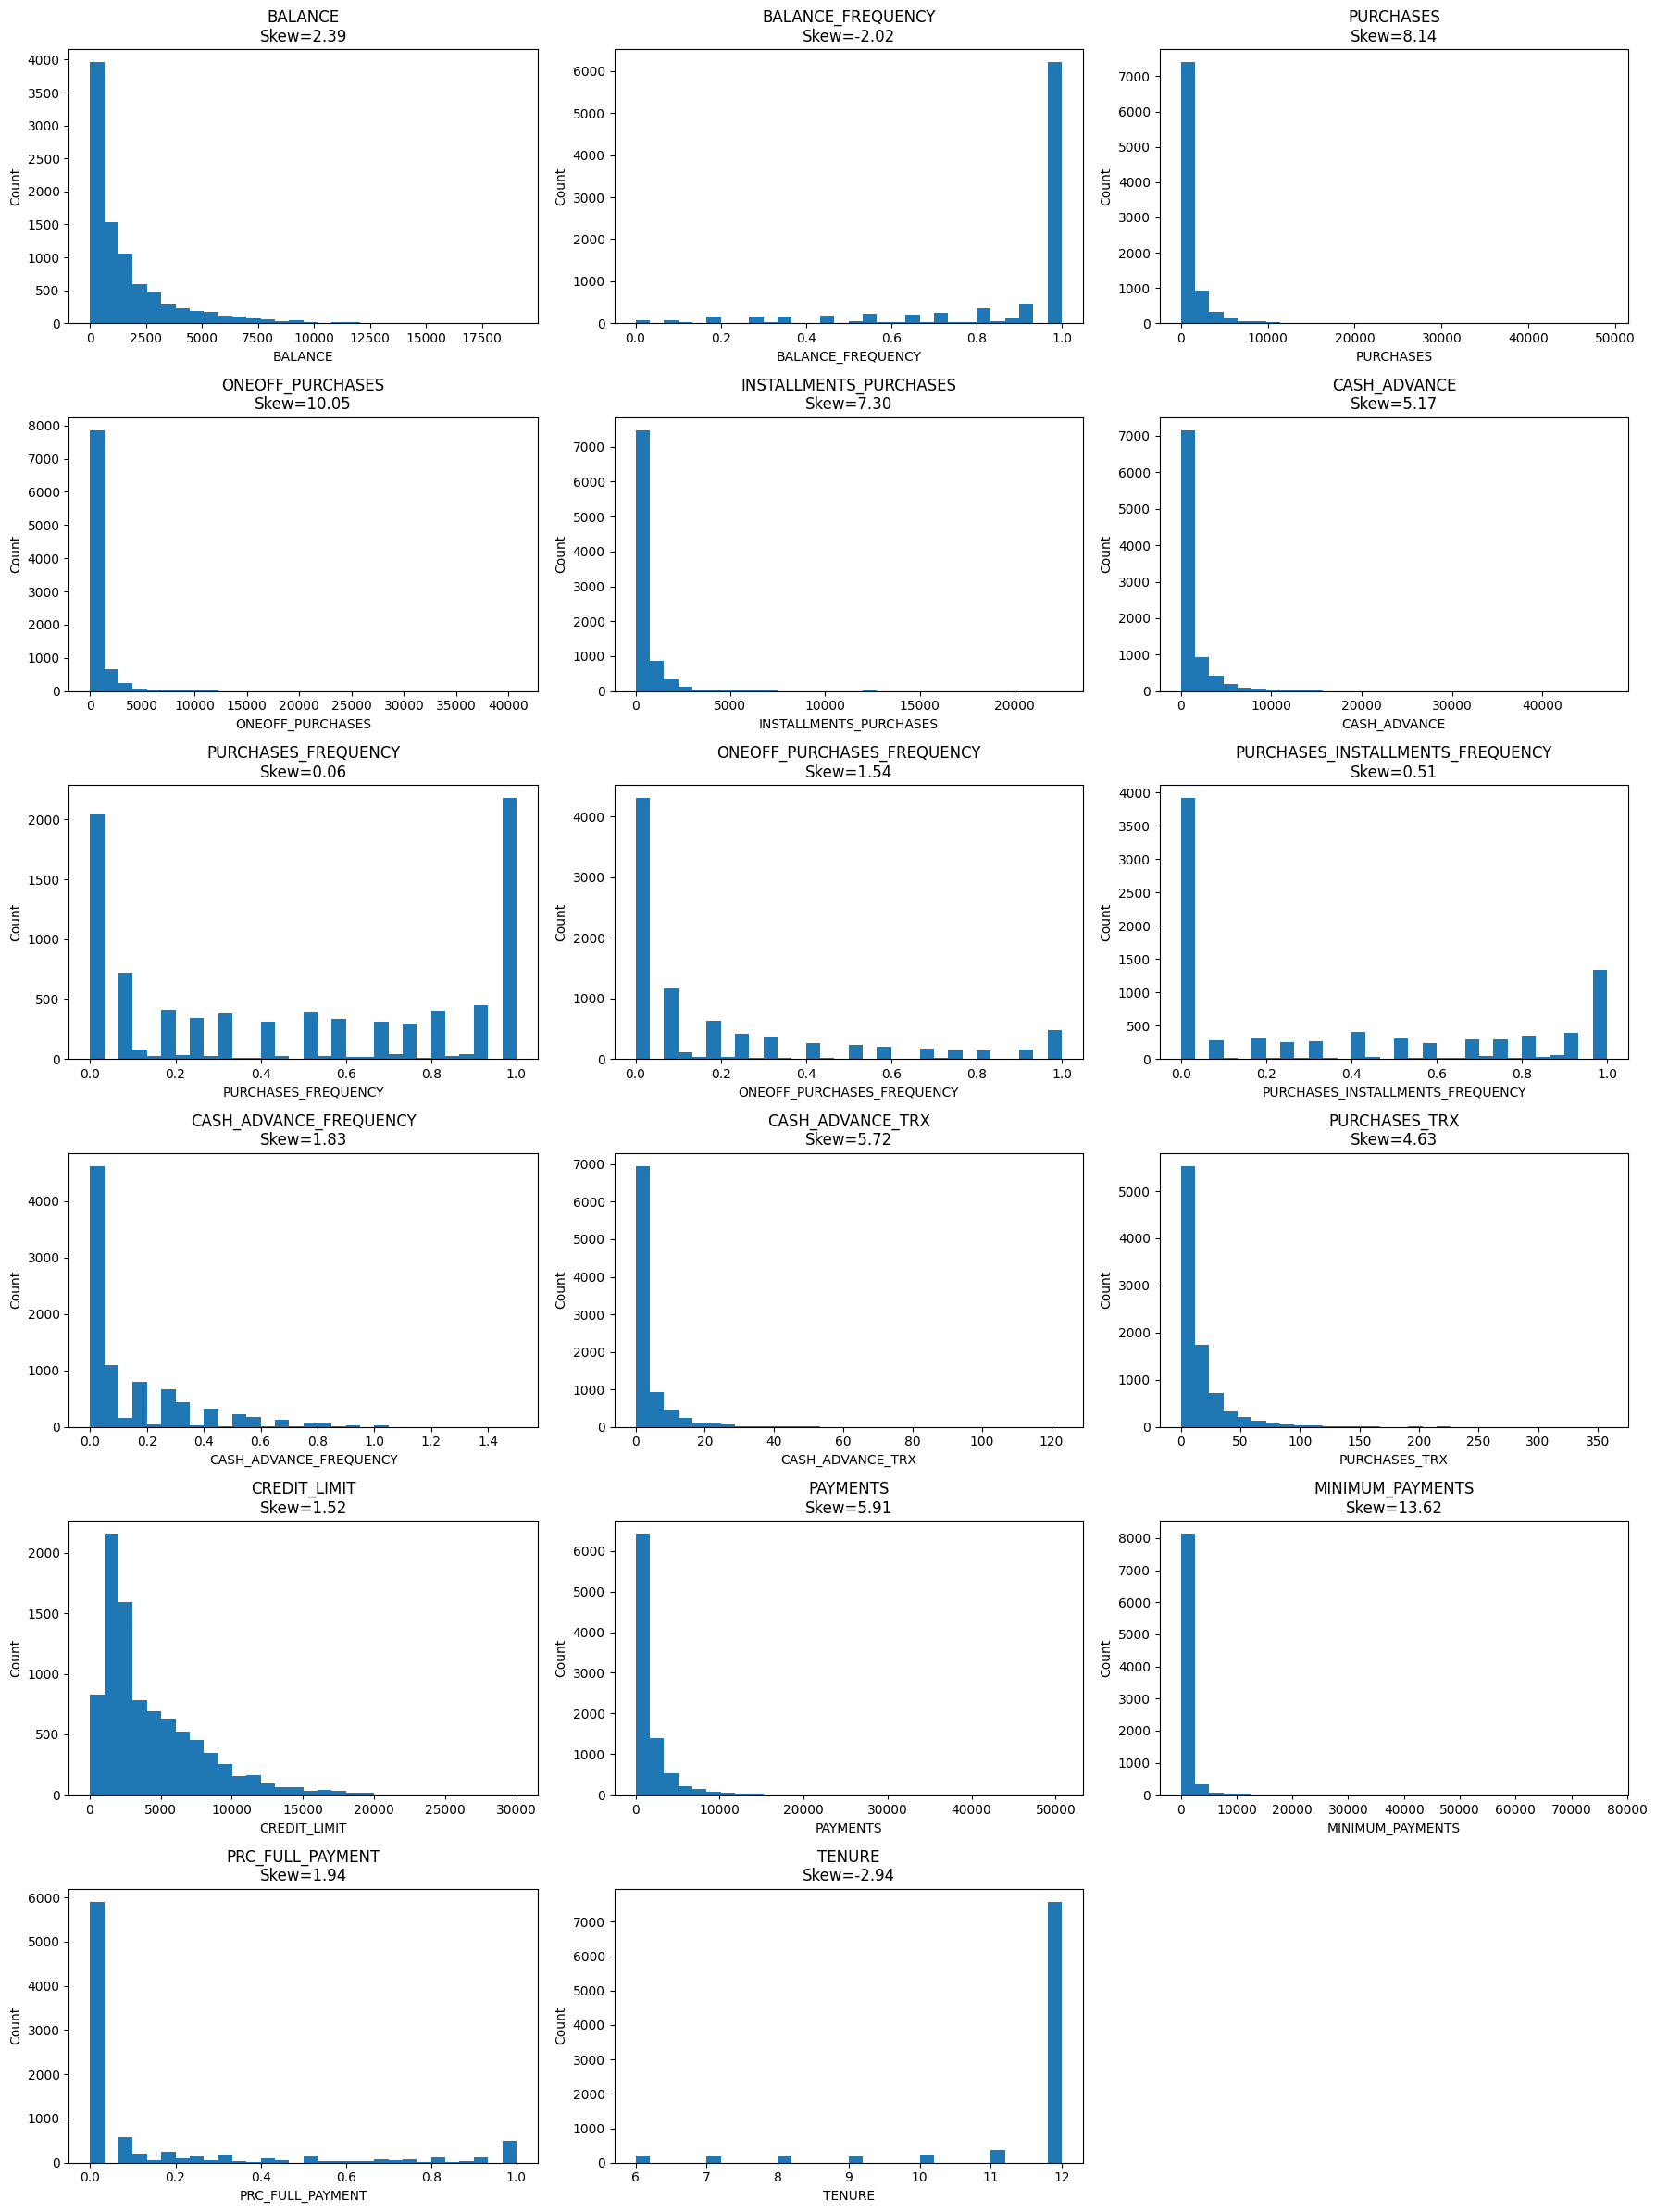

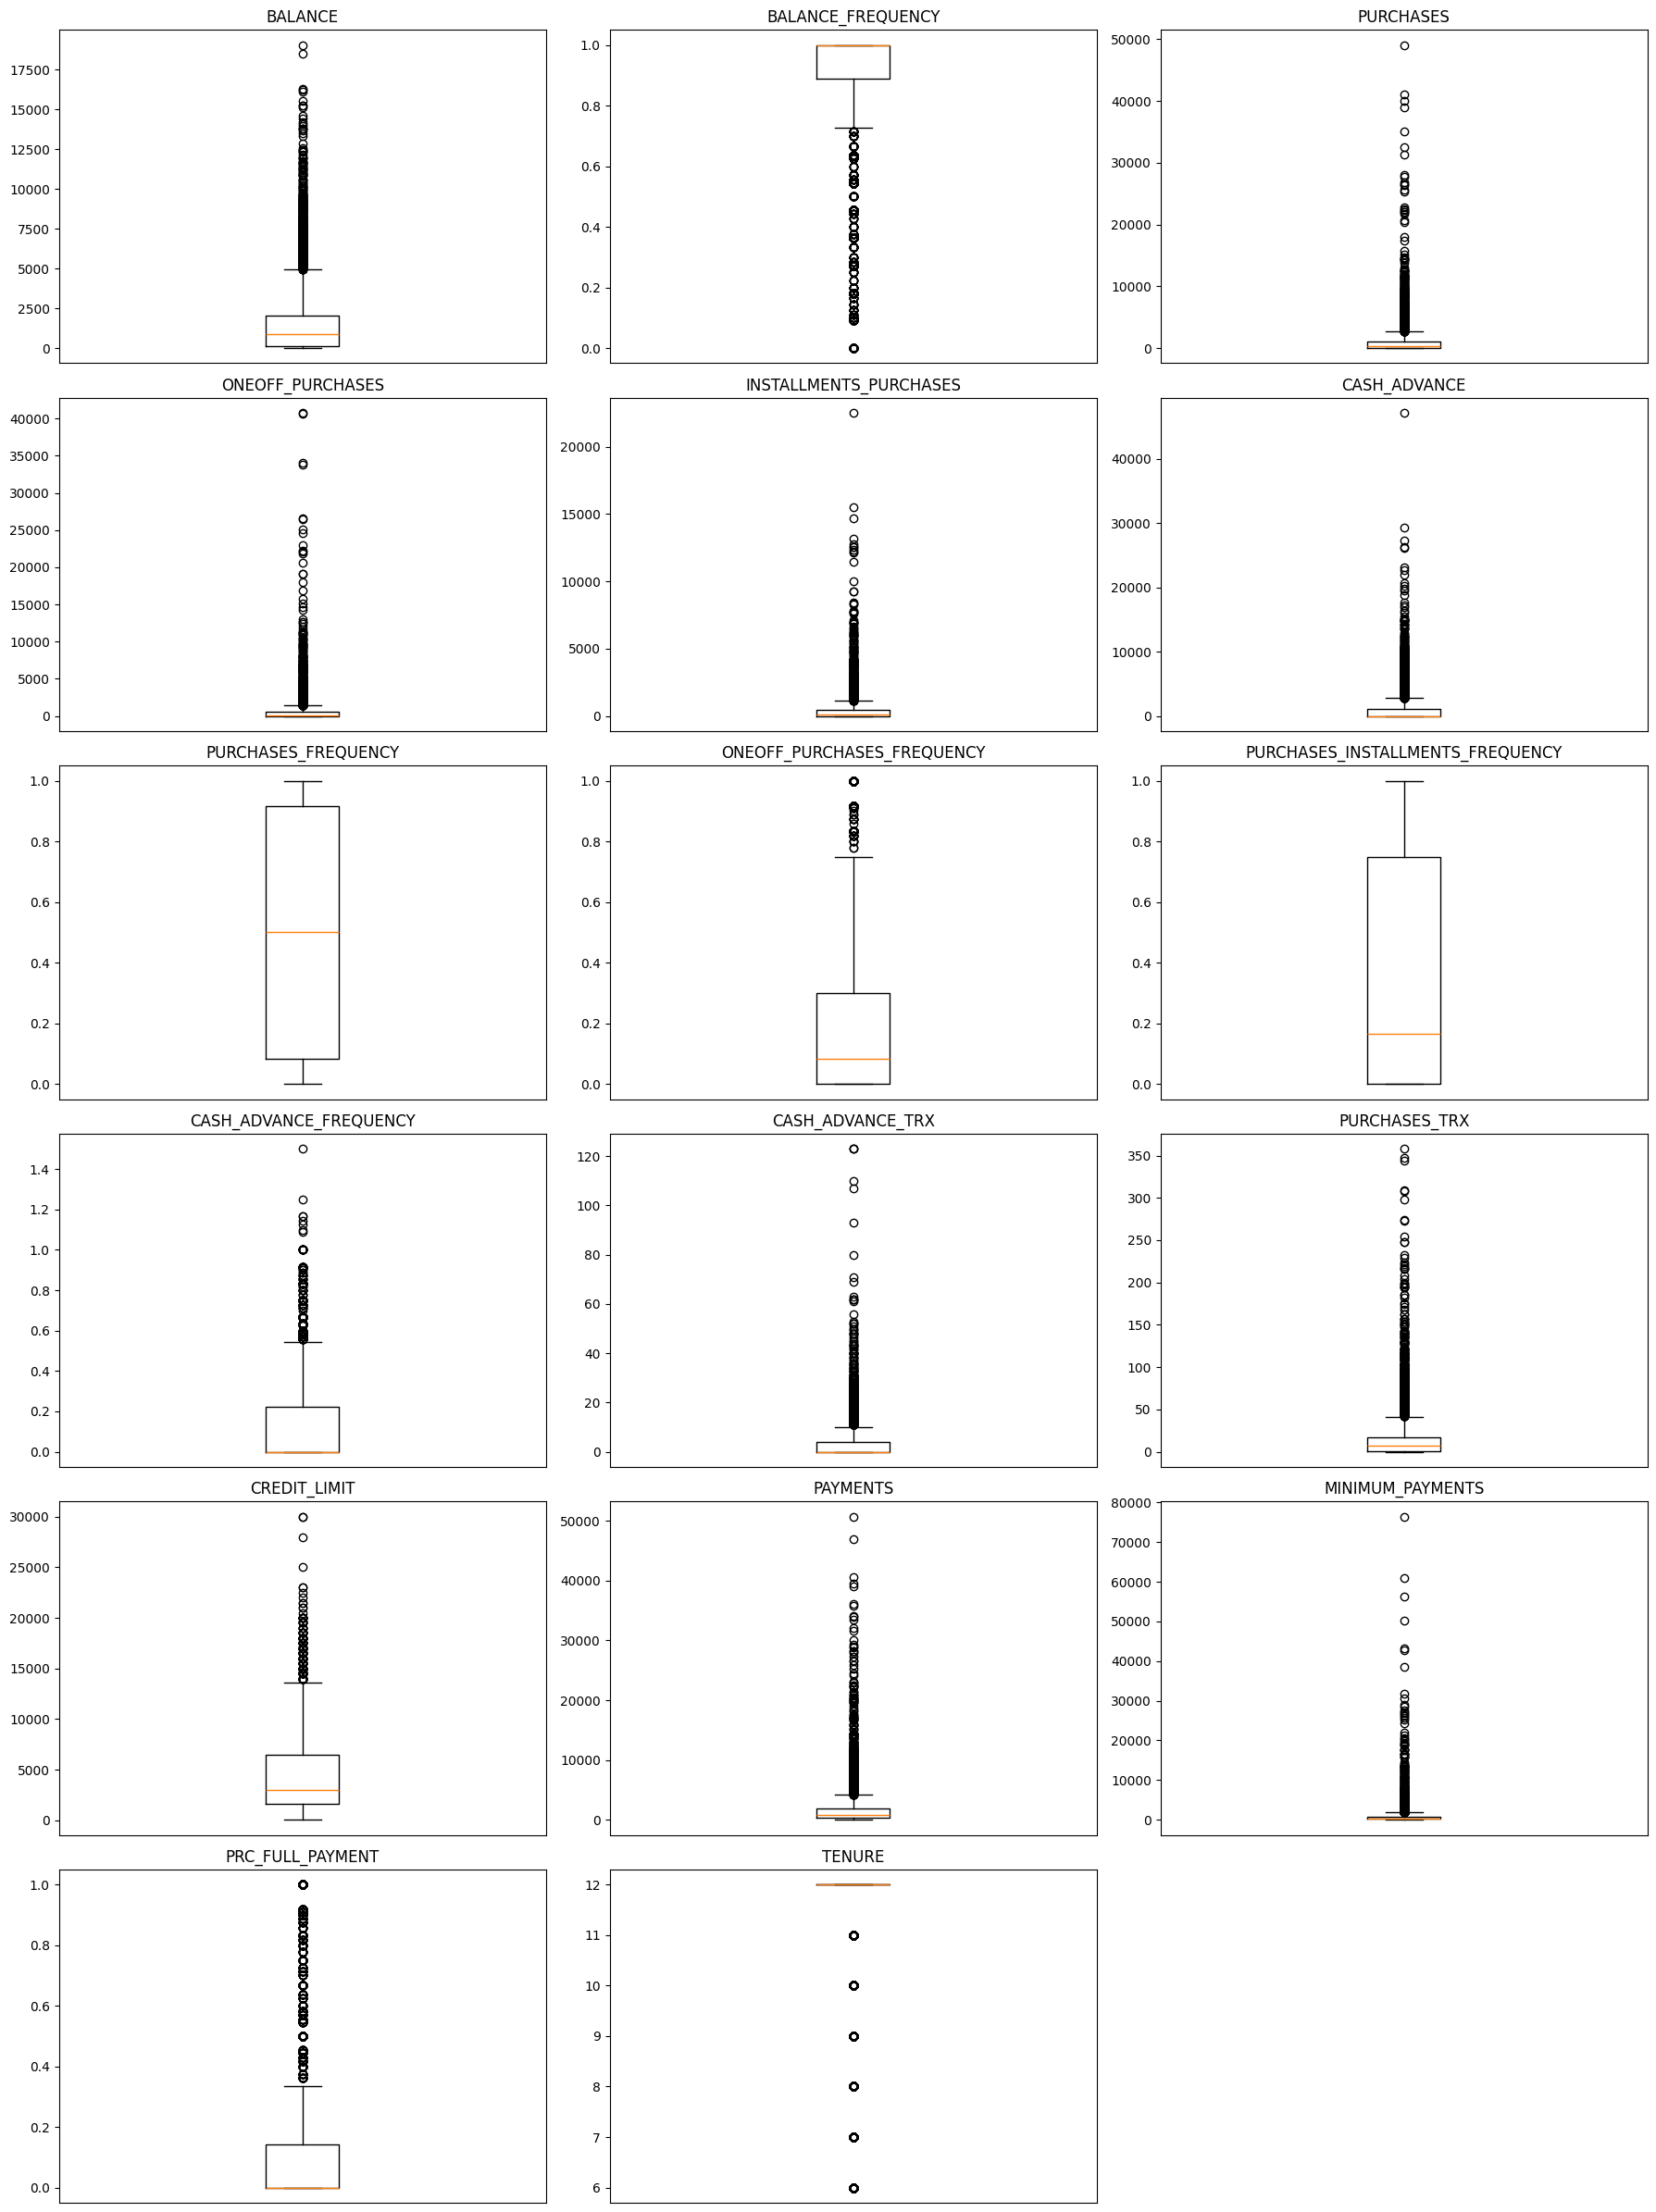

In [2]:
audit_results = run_phase_2_data_audit(
    df=df,
    id_columns=["CUST_ID"],
    show_plots=True
)

schema_report = audit_results["schema_report"]
missingness_report = audit_results["missingness_report"]
distribution_report = audit_results["distribution_report"]

In [3]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer


def phase_3_clean_and_engineer(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if "CUST_ID" in df.columns:
        df = df.drop(columns=["CUST_ID"])

    freq_cols = [c for c in df.columns if "FREQUENCY" in c.upper()]
    if "PRC_FULL_PAYMENT" in df.columns:
        freq_cols.append("PRC_FULL_PAYMENT")
    freq_cols = list(set(freq_cols))

    for col in freq_cols:
        df.loc[~df[col].isna() & ((df[col] < 0) | (df[col] > 1)), col] = np.nan

    missing_numeric_cols = df.select_dtypes(include=[np.number]).columns[df.select_dtypes(include=[np.number]).isna().any()].tolist()
    if missing_numeric_cols:
        imputer = SimpleImputer(strategy="median")
        df[missing_numeric_cols] = imputer.fit_transform(df[missing_numeric_cols])

    tenure = df["TENURE"].replace(0, np.nan) if "TENURE" in df.columns else np.nan
    credit_limit = df["CREDIT_LIMIT"].replace(0, np.nan) if "CREDIT_LIMIT" in df.columns else np.nan
    min_pay = df["MINIMUM_PAYMENTS"].replace(0, np.nan) if "MINIMUM_PAYMENTS" in df.columns else np.nan

    purchases = df["PURCHASES"] if "PURCHASES" in df.columns else 0
    cash_advance = df["CASH_ADVANCE"] if "CASH_ADVANCE" in df.columns else 0
    installments = df["INSTALLMENTS_PURCHASES"] if "INSTALLMENTS_PURCHASES" in df.columns else 0
    payments = df["PAYMENTS"] if "PAYMENTS" in df.columns else 0
    balance = df["BALANCE"] if "BALANCE" in df.columns else 0

    total_spend = purchases + cash_advance

    if "TENURE" in df.columns and "PURCHASES" in df.columns:
        df["MONTHLY_AVG_PURCHASES"] = (purchases / tenure).fillna(0)

    if "TENURE" in df.columns and "CASH_ADVANCE" in df.columns:
        df["MONTHLY_AVG_CASH_ADVANCE"] = (cash_advance / tenure).fillna(0)

    if "PURCHASES" in df.columns and "CASH_ADVANCE" in df.columns:
        df["CASH_ADVANCE_RATIO"] = np.where(total_spend == 0, 0, cash_advance / total_spend)

    if "BALANCE" in df.columns and "CREDIT_LIMIT" in df.columns:
        df["LIMIT_USAGE"] = (balance / credit_limit).replace([np.inf, -np.inf], np.nan).fillna(0)

    if "PAYMENTS" in df.columns and "MINIMUM_PAYMENTS" in df.columns:
        df["PAYMENT_MIN_RATIO"] = (payments / min_pay).replace([np.inf, -np.inf], np.nan).fillna(0)

    if "INSTALLMENTS_PURCHASES" in df.columns and "PURCHASES" in df.columns:
        df["INSTALLMENT_PURCHASE_RATIO"] = np.where(purchases == 0, 0, installments / purchases)

    return df

In [4]:
df_phase3 = phase_3_clean_and_engineer(df)
df_phase3.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,...,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,MONTHLY_AVG_PURCHASES,MONTHLY_AVG_CASH_ADVANCE,CASH_ADVANCE_RATIO,LIMIT_USAGE,PAYMENT_MIN_RATIO,INSTALLMENT_PURCHASE_RATIO
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,...,201.802084,139.509787,0.000000,12,7.950000,0.000000,0.000000,0.040901,1.446508,1.0
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,...,4103.032597,1072.340217,0.222222,12,0.000000,536.912124,1.000000,0.457495,3.826241,0.0
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,...,622.066742,627.284787,0.000000,12,64.430833,0.000000,0.000000,0.332687,0.991682,0.0
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,...,0.000000,312.343947,0.000000,12,124.916667,17.149001,0.120712,0.222223,0.000000,0.0
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,...,678.334763,244.791237,0.000000,12,1.333333,0.000000,0.000000,0.681429,2.771075,0.0


In [5]:
import numpy as np
import pandas as pd


def phase_3b_drop_correlated_features(df: pd.DataFrame, threshold: float = 0.7):
    candidate_cols = [
        "BALANCE",
        "PURCHASES",
        "ONEOFF_PURCHASES",
        "INSTALLMENTS_PURCHASES",
        "CASH_ADVANCE",
        "CREDIT_LIMIT",
        "PAYMENTS",
        "MINIMUM_PAYMENTS",
        "PURCHASES_FREQUENCY",
        "ONEOFF_PURCHASES_FREQUENCY",
        "PURCHASES_INSTALLMENTS_FREQUENCY",
        "CASH_ADVANCE_FREQUENCY",
        "PRC_FULL_PAYMENT",
        "TENURE",
        "MONTHLY_AVG_PURCHASES",
        "MONTHLY_AVG_CASH_ADVANCE",
        "CASH_ADVANCE_RATIO",
        "LIMIT_USAGE",
        "PAYMENT_MIN_RATIO",
        "INSTALLMENT_PURCHASE_RATIO",
    ]
    candidate_cols = [c for c in candidate_cols if c in df.columns]

    # Higher priority = more preferred to keep
    priority = [
        "LIMIT_USAGE",
        "PAYMENT_MIN_RATIO",
        "CASH_ADVANCE_RATIO",
        "INSTALLMENT_PURCHASE_RATIO",
        "MONTHLY_AVG_PURCHASES",
        "MONTHLY_AVG_CASH_ADVANCE",
        "PURCHASES_FREQUENCY",
        "CASH_ADVANCE_FREQUENCY",
        "PRC_FULL_PAYMENT",
        "BALANCE",
        "PURCHASES",
        "ONEOFF_PURCHASES",
        "INSTALLMENTS_PURCHASES",
        "CASH_ADVANCE",
        "PAYMENTS",
        "MINIMUM_PAYMENTS",
        "CREDIT_LIMIT",
        "TENURE",
        "ONEOFF_PURCHASES_FREQUENCY",
        "PURCHASES_INSTALLMENTS_FREQUENCY",
    ]
    rank = {col: i for i, col in enumerate(priority)}

    X = df[candidate_cols].copy()
    corr_matrix = X.corr().abs()

    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = set()
    drop_pairs = []

    for col in upper.columns:
        high_corr = upper[col][upper[col] > threshold]
        for row_col, corr_val in high_corr.items():
            if row_col in to_drop or col in to_drop:
                continue

            rank_row = rank.get(row_col, 10**6)
            rank_col = rank.get(col, 10**6)

            if rank_row <= rank_col:
                keep, drop = row_col, col
            else:
                keep, drop = col, row_col

            to_drop.add(drop)
            drop_pairs.append((keep, drop, corr_val))

    kept_cols = [c for c in candidate_cols if c not in to_drop]
    df_reduced = df[kept_cols].copy()

    drop_log = pd.DataFrame(drop_pairs, columns=["kept_feature", "dropped_feature", "abs_correlation"])
    return df_reduced, kept_cols, drop_log

In [ ]:

df_phase3_reduced, kept_cols, drop_log = phase_3b_drop_correlated_features(df_phase3, threshold=0.7)


In [7]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler


def phase_4_prepare_matrix(df: pd.DataFrame):
    feature_cols = [
        "BALANCE",
        "PURCHASES",
        "ONEOFF_PURCHASES",
        "INSTALLMENTS_PURCHASES",
        "CASH_ADVANCE",
        "CREDIT_LIMIT",
        "PAYMENTS",
        "MINIMUM_PAYMENTS",
        "PURCHASES_FREQUENCY",
        "CASH_ADVANCE_FREQUENCY",
        "PRC_FULL_PAYMENT",
        "MONTHLY_AVG_PURCHASES",
        "MONTHLY_AVG_CASH_ADVANCE",
        "CASH_ADVANCE_RATIO",
        "LIMIT_USAGE",
        "PAYMENT_MIN_RATIO",
        "INSTALLMENT_PURCHASE_RATIO",
    ]
    feature_cols = [c for c in feature_cols if c in df.columns]

    log_cols = [
        "BALANCE",
        "PURCHASES",
        "ONEOFF_PURCHASES",
        "INSTALLMENTS_PURCHASES",
        "CASH_ADVANCE",
        "CREDIT_LIMIT",
        "PAYMENTS",
        "MINIMUM_PAYMENTS",
        "MONTHLY_AVG_PURCHASES",
        "MONTHLY_AVG_CASH_ADVANCE",
        'PAYMENT_MIN_RATIO',
        'LIMIT_USAGE',
    ]
    log_cols = [c for c in log_cols if c in feature_cols]

    X = df[feature_cols].copy()
    X[log_cols] = np.log1p(X[log_cols].clip(lower=0))

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_scaled = pd.DataFrame(X_scaled, columns=feature_cols, index=df.index)
    return X_scaled, feature_cols, log_cols, scaler

In [8]:
X_scaled, feature_cols, log_cols, scaler = phase_4_prepare_matrix(df_phase3_reduced)
X_scaled.head()

,BALANCE,INSTALLMENTS_PURCHASES,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PRC_FULL_PAYMENT,MONTHLY_AVG_PURCHASES,MONTHLY_AVG_CASH_ADVANCE,CASH_ADVANCE_RATIO,LIMIT_USAGE,PAYMENT_MIN_RATIO,INSTALLMENT_PURCHASE_RATIO
0,-1.205218,0.394480,-1.447163,-0.824484,-0.829841,-0.806490,-0.678535,-0.525551,-0.429030,-0.890667,-0.856608,-1.022796,-0.492437,1.410211
1,0.948918,-1.087454,0.926060,1.065033,0.908184,-1.221758,0.586652,0.234227,-1.523373,1.697282,1.399620,0.322182,0.230261,-0.912012
2,0.824993,-1.087454,1.010229,-0.119300,0.450407,1.269843,-0.678535,-0.525551,0.564294,-0.890667,-0.856608,-0.035495,-0.711225,-0.912012
3,0.624653,-1.087454,1.010229,-4.161996,-0.144271,-1.014125,-0.256808,-0.525551,0.891164,0.302372,-0.584255,-0.381199,-1.444107,-0.912012
4,0.271260,-1.087454,-1.224909,-0.064979,-0.351833,-1.014125,-0.678535,-0.525551,-1.100298,-0.890667,-0.856608,0.893219,-0.032167,-0.912012


In [9]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score


def _cluster_metrics(X, labels):
    n_clusters = len(np.unique(labels))
    if n_clusters < 2:
        return {
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "calinski_harabasz": np.nan,
        }
    return {
        "silhouette": silhouette_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels),
    }


def phase_5_scan_models(X_scaled, k_range=range(2, 9), random_state=42):
    kmeans_rows = []
    gmm_rows = []

    for k in k_range:
        km = KMeans(n_clusters=k, n_init=20, random_state=random_state)
        km_labels = km.fit_predict(X_scaled)
        km_metrics = _cluster_metrics(X_scaled, km_labels)
        kmeans_rows.append({
            "model": "KMeans",
            "k": k,
            "inertia": km.inertia_,
            **km_metrics
        })

        for cov in ["full", "diag", "tied", "spherical"]:
            gmm = GaussianMixture(
                n_components=k,
                covariance_type=cov,
                n_init=10,
                random_state=random_state
            )
            gmm_labels = gmm.fit_predict(X_scaled)
            gmm_metrics = _cluster_metrics(X_scaled, gmm_labels)
            gmm_rows.append({
                "model": "GMM",
                "k": k,
                "covariance_type": cov,
                "bic": gmm.bic(X_scaled),
                "aic": gmm.aic(X_scaled),
                **gmm_metrics
            })

    kmeans_results = pd.DataFrame(kmeans_rows)
    gmm_results = pd.DataFrame(gmm_rows)
    return kmeans_results, gmm_results

In [10]:
kmeans_results, gmm_results = phase_5_scan_models(X_scaled)
kmeans_results.sort_values("silhouette", ascending=False).head()
gmm_results.sort_values("silhouette", ascending=False).head()

,model,k,covariance_type,bic,aic,silhouette,davies_bouldin,calinski_harabasz
2,GMM,2,tied,230533.311995,229581.991215,0.267881,1.498252,3448.111018
3,GMM,2,spherical,322693.933875,322473.852202,0.253200,1.343431,3062.716295
1,GMM,2,diag,134471.483884,134066.817582,0.247348,1.606481,3161.880179
0,GMM,2,full,50250.137835,48553.379129,0.247348,1.606481,3161.880179
7,GMM,3,spherical,308408.097787,308074.425573,0.236214,1.600905,2954.313197


In [11]:
def phase_5_fit_final_model(X_scaled, model="kmeans", k=3, covariance_type="full", random_state=42):
    if model == "kmeans":
        fitted_model = KMeans(n_clusters=k, n_init=20, random_state=random_state)
        labels = fitted_model.fit_predict(X_scaled)
    elif model == "gmm":
        fitted_model = GaussianMixture(
            n_components=k,
            covariance_type=covariance_type,
            n_init=10,
            random_state=random_state
        )
        labels = fitted_model.fit_predict(X_scaled)
    else:
        raise ValueError("model must be 'kmeans' or 'gmm'")

    metrics = _cluster_metrics(X_scaled, labels)
    return fitted_model, labels, metrics

In [12]:
final_model, final_labels, final_metrics = phase_5_fit_final_model(
    X_scaled,
    model="kmeans",
    k=3
)
final_metrics

{'silhouette': 0.24032370881705561,
 'davies_bouldin': 1.5893767495496487,
 'calinski_harabasz': 3049.614903837767}

In [13]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_samples


def phase_6_validate_and_profile(df: pd.DataFrame, X_scaled, labels, feature_cols):
    labels = np.asarray(labels)

    sil_samples = silhouette_samples(X_scaled, labels)
    sil_df = pd.DataFrame({
        "Cluster": labels,
        "silhouette_sample": sil_samples
    })

    cluster_validation = sil_df.groupby("Cluster").agg(
        cluster_size=("Cluster", "size"),
        silhouette_mean=("silhouette_sample", "mean"),
        silhouette_min=("silhouette_sample", "min"),
        silhouette_std=("silhouette_sample", "std")
    ).reset_index()

    df_labeled = df.copy()
    df_labeled["Cluster"] = labels

    profile_features = [c for c in feature_cols if c in df_labeled.columns]

    cluster_profile = df_labeled.groupby("Cluster")[profile_features].agg(["mean", "median"])
    cluster_profile.columns = [f"{col}_{stat}" for col, stat in cluster_profile.columns]
    cluster_profile = cluster_profile.reset_index()

    cluster_size = df_labeled["Cluster"].value_counts(normalize=True).sort_index() * 100
    cluster_profile["population_pct"] = cluster_profile["Cluster"].map(cluster_size)

    return df_labeled, cluster_validation, cluster_profile

In [14]:
df_labeled, cluster_validation, cluster_profile = phase_6_validate_and_profile(
    df_phase3,
    X_scaled,
    final_labels,
    feature_cols
)

cluster_validation
cluster_profile

,Cluster,BALANCE_mean,BALANCE_median,INSTALLMENTS_PURCHASES_mean,INSTALLMENTS_PURCHASES_median,CREDIT_LIMIT_mean,CREDIT_LIMIT_median,PAYMENTS_mean,PAYMENTS_median,MINIMUM_PAYMENTS_mean,...,MONTHLY_AVG_CASH_ADVANCE_median,CASH_ADVANCE_RATIO_mean,CASH_ADVANCE_RATIO_median,LIMIT_USAGE_mean,LIMIT_USAGE_median,PAYMENT_MIN_RATIO_mean,PAYMENT_MIN_RATIO_median,INSTALLMENT_PURCHASE_RATIO_mean,INSTALLMENT_PURCHASE_RATIO_median,population_pct
0,0,190.526722,82.980060,503.465750,250.45,4328.496129,3000.0,1317.161797,634.000055,169.008241,...,0.000000,0.029300,0.0,0.058057,0.026403,17.745194,4.636024,0.588518,0.735495,38.670391
1,1,2250.466673,1530.402075,3.004964,0.00,4157.432768,3000.0,1707.614851,797.429198,982.349367,...,117.942631,0.932119,1.0,0.584643,0.611711,4.379505,1.110465,0.025205,0.000000,31.374302
2,2,2619.666656,1765.263223,719.180351,363.98,5061.108474,4000.0,2296.888473,1232.660721,1573.495343,...,0.000000,0.253336,0.0,0.610928,0.606019,2.747390,1.205022,0.524924,0.498275,29.955307


In [15]:
def phase_6_name_segments(cluster_profile: pd.DataFrame):
    profile = cluster_profile.copy()
    segment_names = {}

    for _, row in profile.iterrows():
        c = row["Cluster"]

        limit_usage = row["LIMIT_USAGE_mean"] if "LIMIT_USAGE_mean" in row else 0
        cash_ratio = row["CASH_ADVANCE_RATIO_mean"] if "CASH_ADVANCE_RATIO_mean" in row else 0
        full_pay = row["PRC_FULL_PAYMENT_mean"] if "PRC_FULL_PAYMENT_mean" in row else 0
        monthly_purchases = row["MONTHLY_AVG_PURCHASES_mean"] if "MONTHLY_AVG_PURCHASES_mean" in row else 0

        if cash_ratio > 0.5 and limit_usage > 0.5:
            name = "Cash Dependent"
        elif full_pay > 0.5 and monthly_purchases > profile["MONTHLY_AVG_PURCHASES_mean"].median():
            name = "Active Transactor"
        elif limit_usage < 0.3 and monthly_purchases < profile["MONTHLY_AVG_PURCHASES_mean"].median():
            name = "Low Engager"
        else:
            name = "Mixed Behavior"

        segment_names[c] = name

    profile["Segment_Name"] = profile["Cluster"].map(segment_names)
    return profile, segment_names

In [16]:
cluster_profile_named, segment_names = phase_6_name_segments(cluster_profile)
cluster_profile_named

,Cluster,BALANCE_mean,BALANCE_median,INSTALLMENTS_PURCHASES_mean,INSTALLMENTS_PURCHASES_median,CREDIT_LIMIT_mean,CREDIT_LIMIT_median,PAYMENTS_mean,PAYMENTS_median,MINIMUM_PAYMENTS_mean,...,CASH_ADVANCE_RATIO_mean,CASH_ADVANCE_RATIO_median,LIMIT_USAGE_mean,LIMIT_USAGE_median,PAYMENT_MIN_RATIO_mean,PAYMENT_MIN_RATIO_median,INSTALLMENT_PURCHASE_RATIO_mean,INSTALLMENT_PURCHASE_RATIO_median,population_pct,Segment_Name
0,0,190.526722,82.980060,503.465750,250.45,4328.496129,3000.0,1317.161797,634.000055,169.008241,...,0.029300,0.0,0.058057,0.026403,17.745194,4.636024,0.588518,0.735495,38.670391,Mixed Behavior
1,1,2250.466673,1530.402075,3.004964,0.00,4157.432768,3000.0,1707.614851,797.429198,982.349367,...,0.932119,1.0,0.584643,0.611711,4.379505,1.110465,0.025205,0.000000,31.374302,Cash Dependent
2,2,2619.666656,1765.263223,719.180351,363.98,5061.108474,4000.0,2296.888473,1232.660721,1573.495343,...,0.253336,0.0,0.610928,0.606019,2.747390,1.205022,0.524924,0.498275,29.955307,Mixed Behavior


In [17]:
df_labeled["Segment_Name"] = df_labeled["Cluster"].map(segment_names)
df_labeled.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,...,PRC_FULL_PAYMENT,TENURE,MONTHLY_AVG_PURCHASES,MONTHLY_AVG_CASH_ADVANCE,CASH_ADVANCE_RATIO,LIMIT_USAGE,PAYMENT_MIN_RATIO,INSTALLMENT_PURCHASE_RATIO,Cluster,Segment_Name
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,...,0.000000,12,7.950000,0.000000,0.000000,0.040901,1.446508,1.0,0,Mixed Behavior
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,...,0.222222,12,0.000000,536.912124,1.000000,0.457495,3.826241,0.0,1,Cash Dependent
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,12,64.430833,0.000000,0.000000,0.332687,0.991682,0.0,2,Mixed Behavior
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,...,0.000000,12,124.916667,17.149001,0.120712,0.222223,0.000000,0.0,1,Cash Dependent
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,...,0.000000,12,1.333333,0.000000,0.000000,0.681429,2.771075,0.0,1,Cash Dependent


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_phase_7_kmeans_metrics(kmeans_results: pd.DataFrame):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    axes[0, 0].plot(kmeans_results["k"], kmeans_results["inertia"], marker="o")
    axes[0, 0].set_title("KMeans Inertia")
    axes[0, 0].set_xlabel("k")

    axes[0, 1].plot(kmeans_results["k"], kmeans_results["silhouette"], marker="o")
    axes[0, 1].set_title("KMeans Silhouette")
    axes[0, 1].set_xlabel("k")

    axes[1, 0].plot(kmeans_results["k"], kmeans_results["davies_bouldin"], marker="o")
    axes[1, 0].set_title("KMeans Davies-Bouldin")
    axes[1, 0].set_xlabel("k")

    axes[1, 1].plot(kmeans_results["k"], kmeans_results["calinski_harabasz"], marker="o")
    axes[1, 1].set_title("KMeans Calinski-Harabasz")
    axes[1, 1].set_xlabel("k")

    plt.tight_layout()
    plt.show()


def plot_phase_7_gmm_metrics(gmm_results: pd.DataFrame):
    cov_types = gmm_results["covariance_type"].unique()
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    for cov in cov_types:
        sub = gmm_results[gmm_results["covariance_type"] == cov]
        axes[0, 0].plot(sub["k"], sub["bic"], marker="o", label=cov)
        axes[0, 1].plot(sub["k"], sub["aic"], marker="o", label=cov)
        axes[1, 0].plot(sub["k"], sub["silhouette"], marker="o", label=cov)
        axes[1, 1].plot(sub["k"], sub["davies_bouldin"], marker="o", label=cov)

    axes[0, 0].set_title("GMM BIC")
    axes[0, 1].set_title("GMM AIC")
    axes[1, 0].set_title("GMM Silhouette")
    axes[1, 1].set_title("GMM Davies-Bouldin")

    for ax in axes.ravel():
        ax.set_xlabel("k")
        ax.legend()

    plt.tight_layout()
    plt.show()


def plot_phase_7_cluster_scatter(X_scaled, labels, feature_names=None):
    X_plot = X_scaled.values if isinstance(X_scaled, pd.DataFrame) else X_scaled
    labels = np.asarray(labels)

    if X_plot.shape[1] < 2:
        raise ValueError("Need at least 2 features to plot cluster scatter.")

    plt.figure(figsize=(8, 6))
    plt.scatter(X_plot[:, 0], X_plot[:, 1], c=labels, s=25, alpha=0.7)
    plt.xlabel(feature_names[0] if feature_names is not None else "Feature 1")
    plt.ylabel(feature_names[1] if feature_names is not None else "Feature 2")
    plt.title("Final Cluster Scatter")
    plt.tight_layout()
    plt.show()


def plot_phase_7_cluster_sizes(cluster_validation: pd.DataFrame):
    plt.figure(figsize=(7, 5))
    plt.bar(cluster_validation["Cluster"].astype(str), cluster_validation["cluster_size"])
    plt.xlabel("Cluster")
    plt.ylabel("Size")
    plt.title("Cluster Sizes")
    plt.tight_layout()
    plt.show()


def plot_phase_7_profile_heatmap(cluster_profile_named: pd.DataFrame, value_suffix="_mean"):
    df_plot = cluster_profile_named.copy()

    keep_cols = [c for c in df_plot.columns if c.endswith(value_suffix)]
    if not keep_cols:
        raise ValueError(f"No columns ending with {value_suffix} found.")

    heatmap_df = df_plot.set_index("Cluster")[keep_cols]

    data = heatmap_df.values
    fig, ax = plt.subplots(figsize=(max(10, len(keep_cols) * 0.7), 5))
    im = ax.imshow(data, aspect="auto")

    ax.set_xticks(np.arange(len(keep_cols)))
    ax.set_xticklabels(keep_cols, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(heatmap_df.index)))
    ax.set_yticklabels(heatmap_df.index.astype(str))

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, f"{data[i, j]:.2f}", ha="center", va="center", fontsize=8)

    ax.set_title("Cluster Profile Heatmap")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


def run_phase_7_visuals(
    kmeans_results,
    gmm_results,
    X_scaled,
    final_labels,
    cluster_validation,
    cluster_profile_named
):
    plot_phase_7_kmeans_metrics(kmeans_results)
    plot_phase_7_gmm_metrics(gmm_results)

    feature_names = X_scaled.columns.tolist() if isinstance(X_scaled, pd.DataFrame) else None
    plot_phase_7_cluster_scatter(X_scaled, final_labels, feature_names=feature_names)

    plot_phase_7_cluster_sizes(cluster_validation)
    plot_phase_7_profile_heatmap(cluster_profile_named)

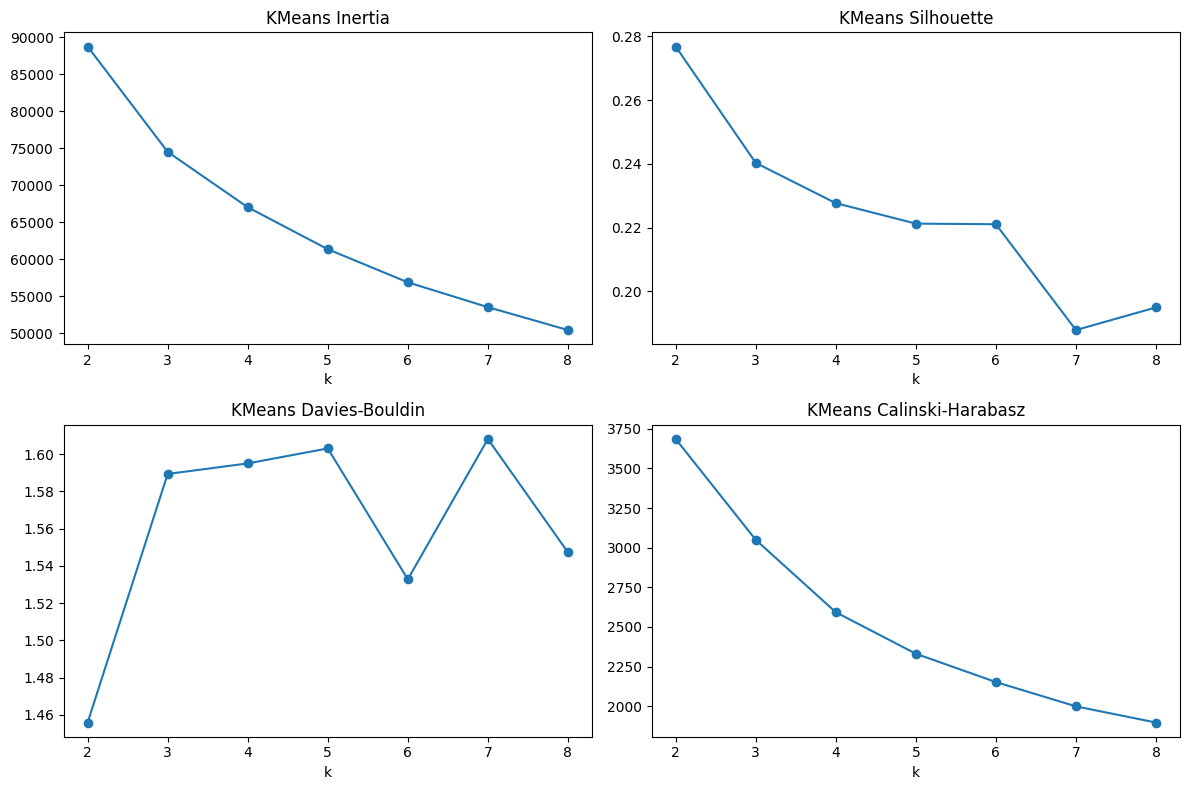

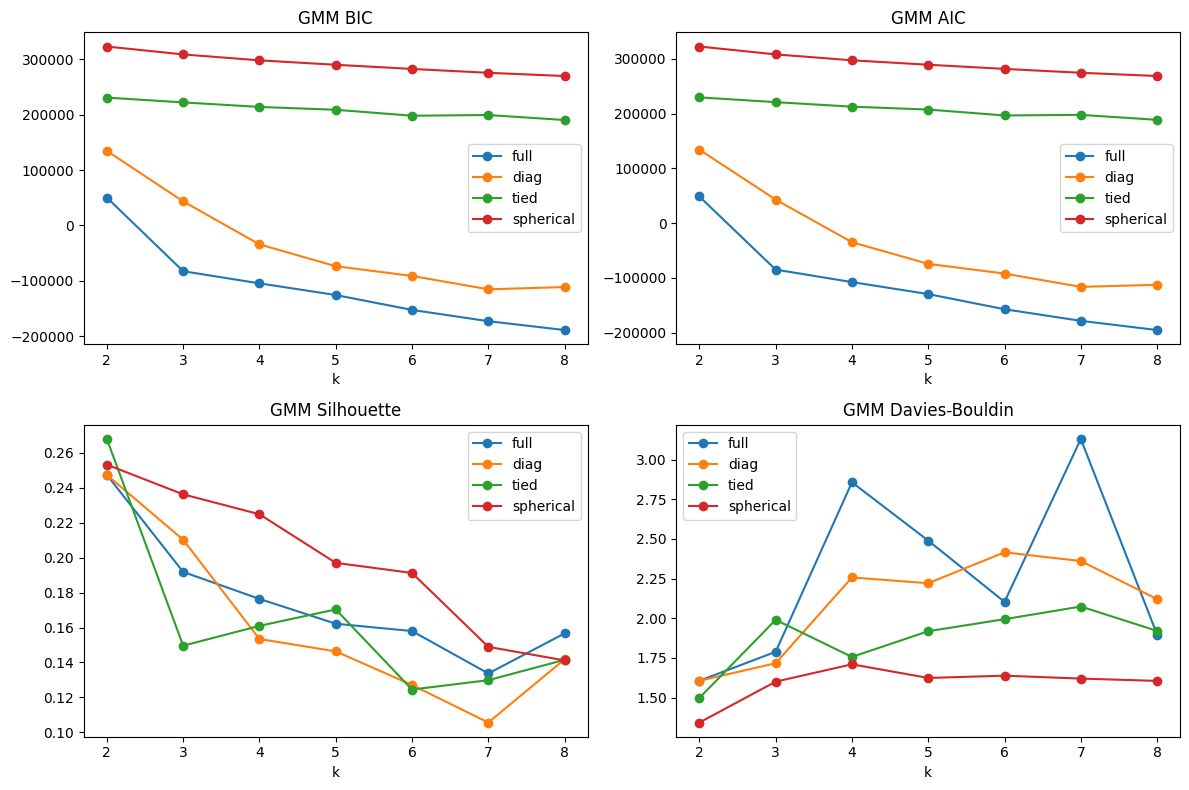

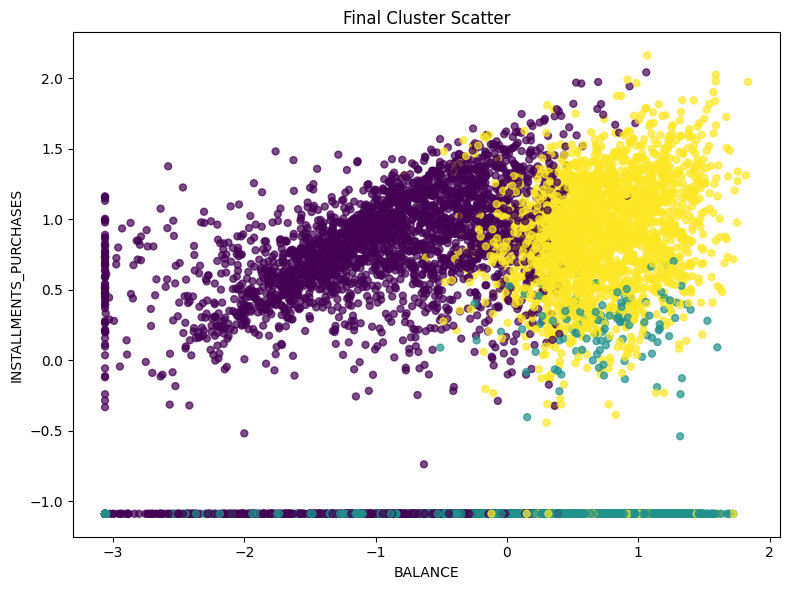

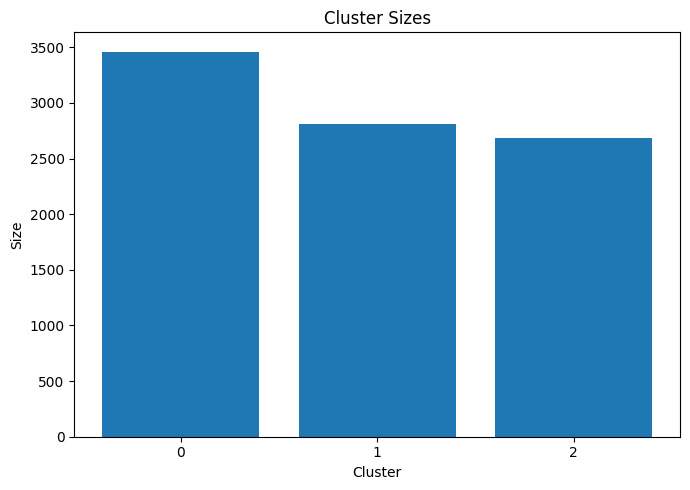

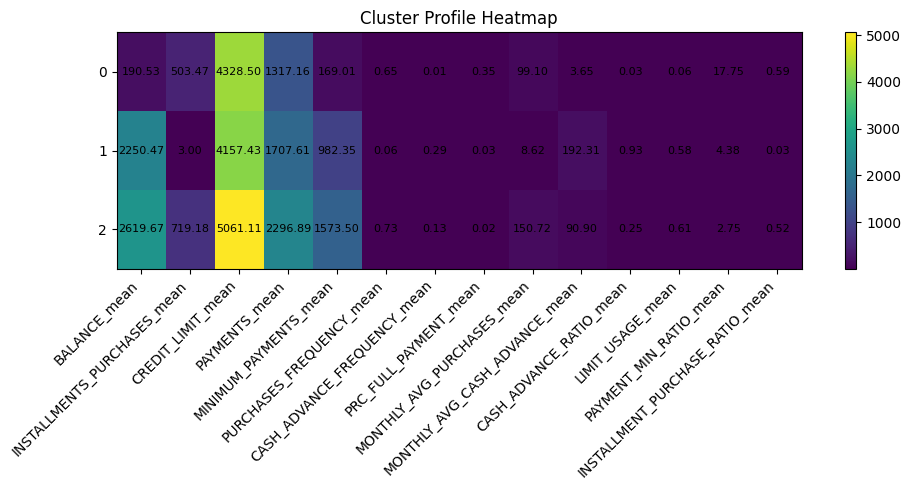

In [19]:
run_phase_7_visuals(
    kmeans_results=kmeans_results,
    gmm_results=gmm_results,
    X_scaled=X_scaled,
    final_labels=final_labels,
    cluster_validation=cluster_validation,
    cluster_profile_named=cluster_profile_named
)